<a href="https://colab.research.google.com/github/premnavagire/Chest_Xray_Detection/blob/main/MDM_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""Fast Chest X-ray Classification using Traditional ML (HOG + Linear SVM)
   Broken into clean notebook cells with preprocessing visualization.
"""

# ============================================================
# CELL 1 — Install packages & Unzip Dataset
# ============================================================

!pip install -q scikit-learn matplotlib seaborn scikit-image

import os
import zipfile

zip_filename = "archive (15).zip"
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete.")
print("Contents:", os.listdir(extract_path))


✅ Extraction complete.
Contents: ['train', 'test']


In [ ]:

# ============================================================
# CELL 2 — Locate Train / Test Directories & Show Class Info
# ============================================================

def find_train_test(base_path):
    train_dir = None
    test_dir = None
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs:
            train_dir = os.path.join(root, 'train')
        if 'test' in dirs:
            test_dir = os.path.join(root, 'test')
    return train_dir, test_dir

train_dir, test_dir = find_train_test(extract_path)
if train_dir is None or test_dir is None:
    raise ValueError("Could not find 'train' and 'test' folders.")

print(f"📁 Train dir : {train_dir}")
print(f"📁 Test  dir : {test_dir}")

class_names = [d for d in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, d))]
print(f"\n🏷️  Classes found ({len(class_names)}): {class_names}")

# Count images per class
for cls in class_names:
    n_train = len(os.listdir(os.path.join(train_dir, cls)))
    n_test  = len(os.listdir(os.path.join(test_dir,  cls)))
    print(f"   {cls:20s} → train: {n_train:5d}  |  test: {n_test:5d}")

📁 Train dir : /content/dataset/train
📁 Test  dir : /content/dataset/test

🏷️  Classes found (3): ['VIRAL_PNEUMONIA', 'NORMAL', 'BACTERIAL_PNEUMONIA']
   VIRAL_PNEUMONIA      → train:  4014  |  test:   147
   NORMAL               → train:  4044  |  test:   231
   BACTERIAL_PNEUMONIA  → train:  7560  |  test:   240


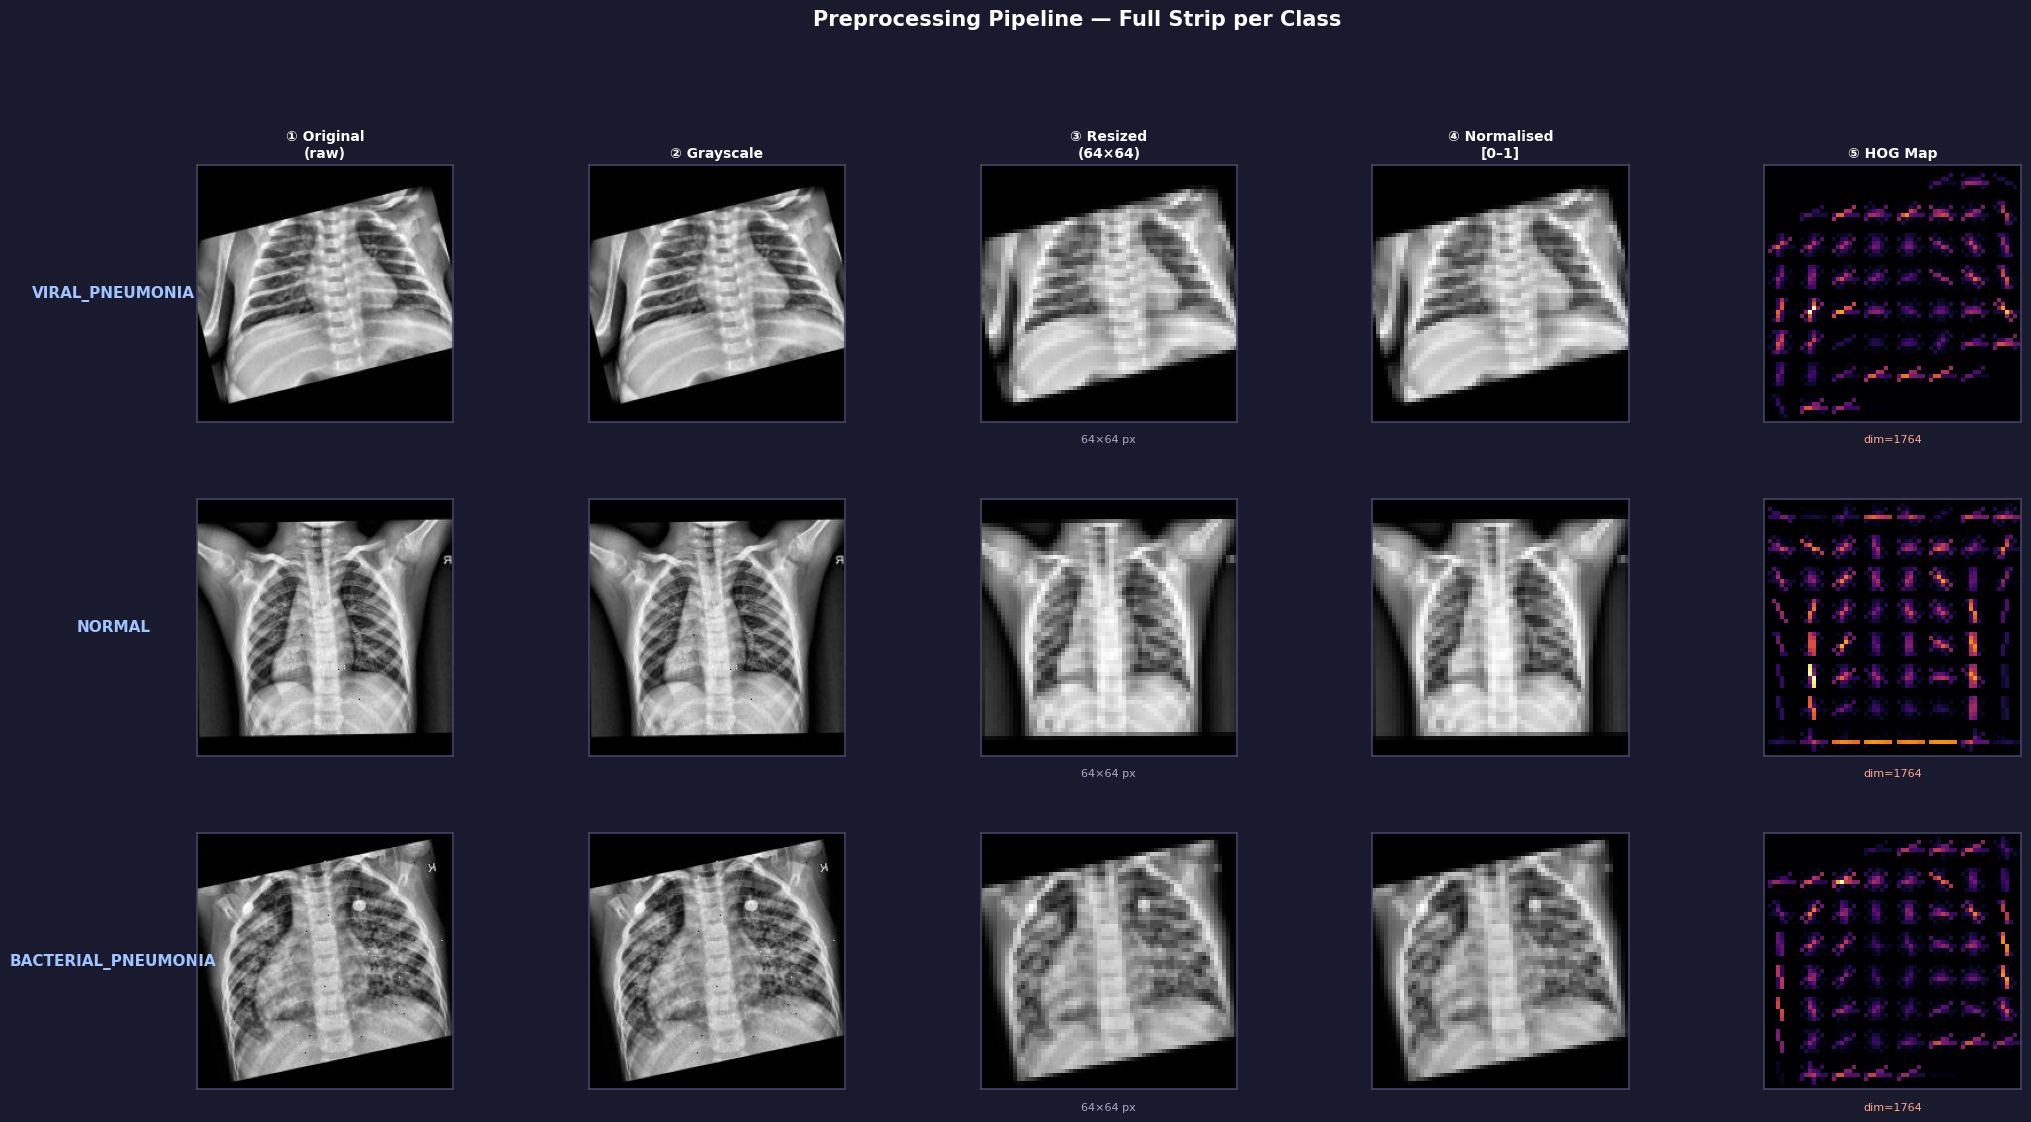

✅ Plot A saved: preproc_A_full_pipeline.png


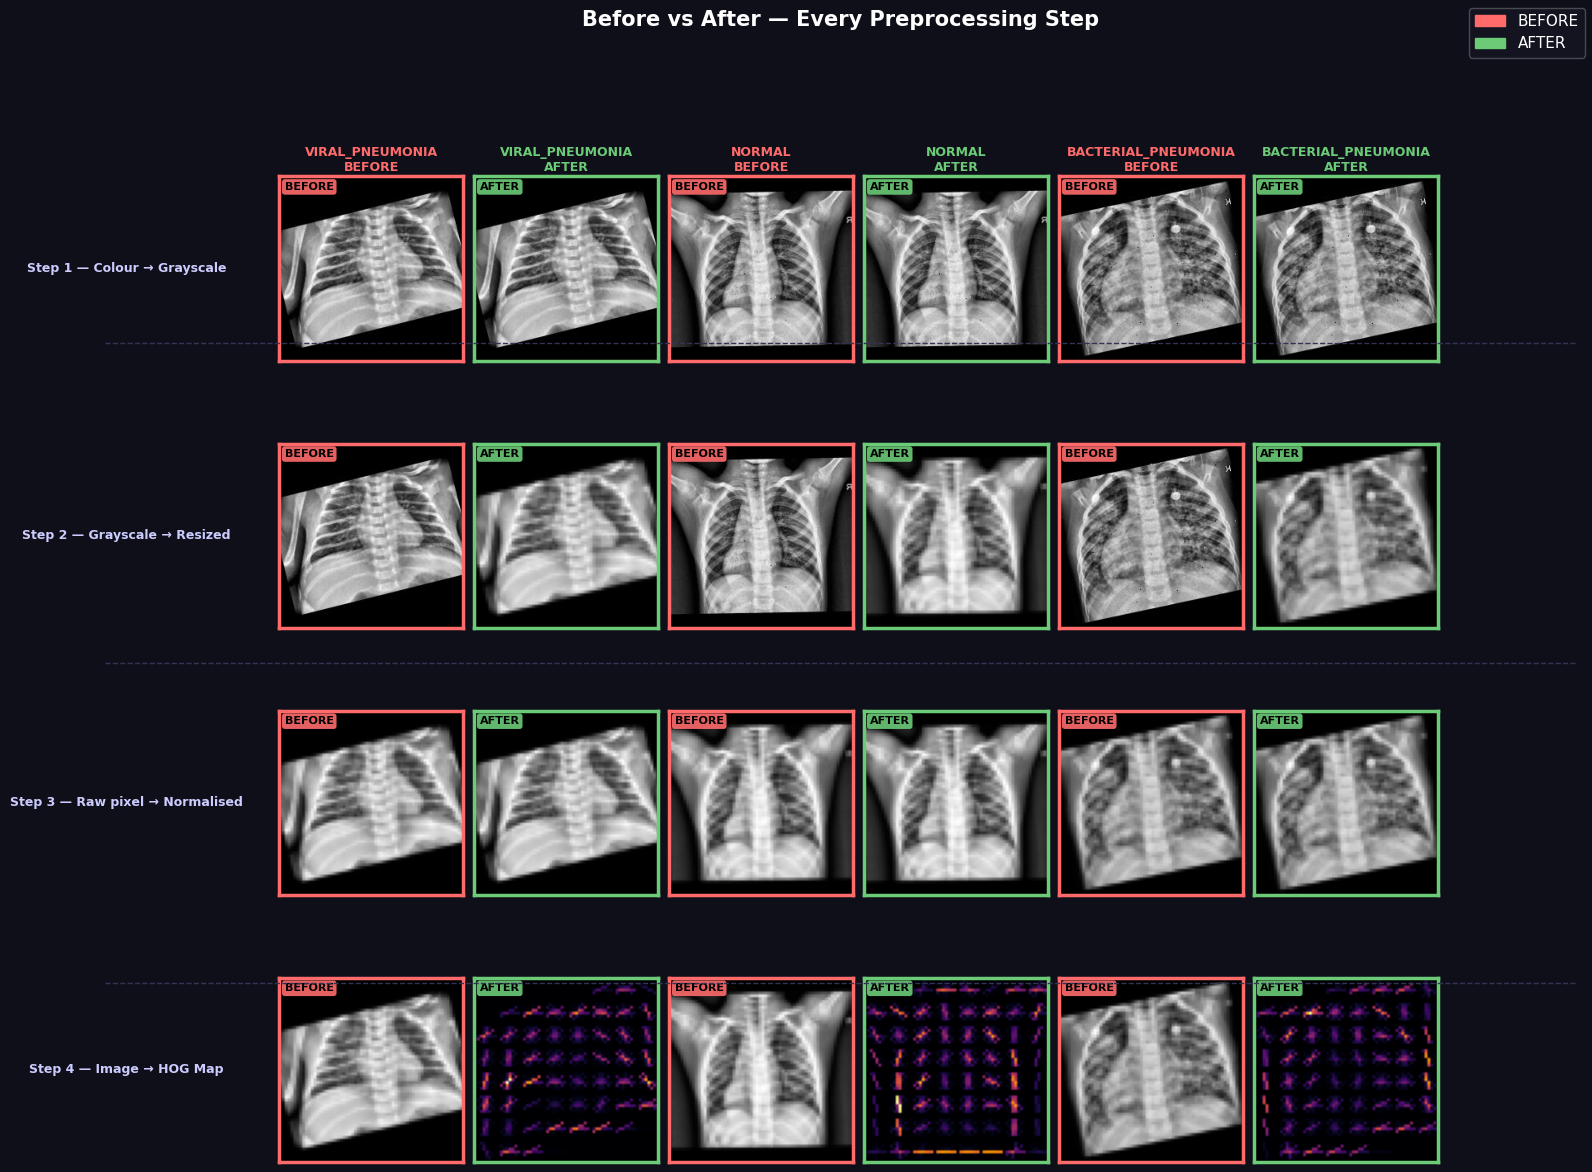

✅ Plot B saved: preproc_B_before_after.png


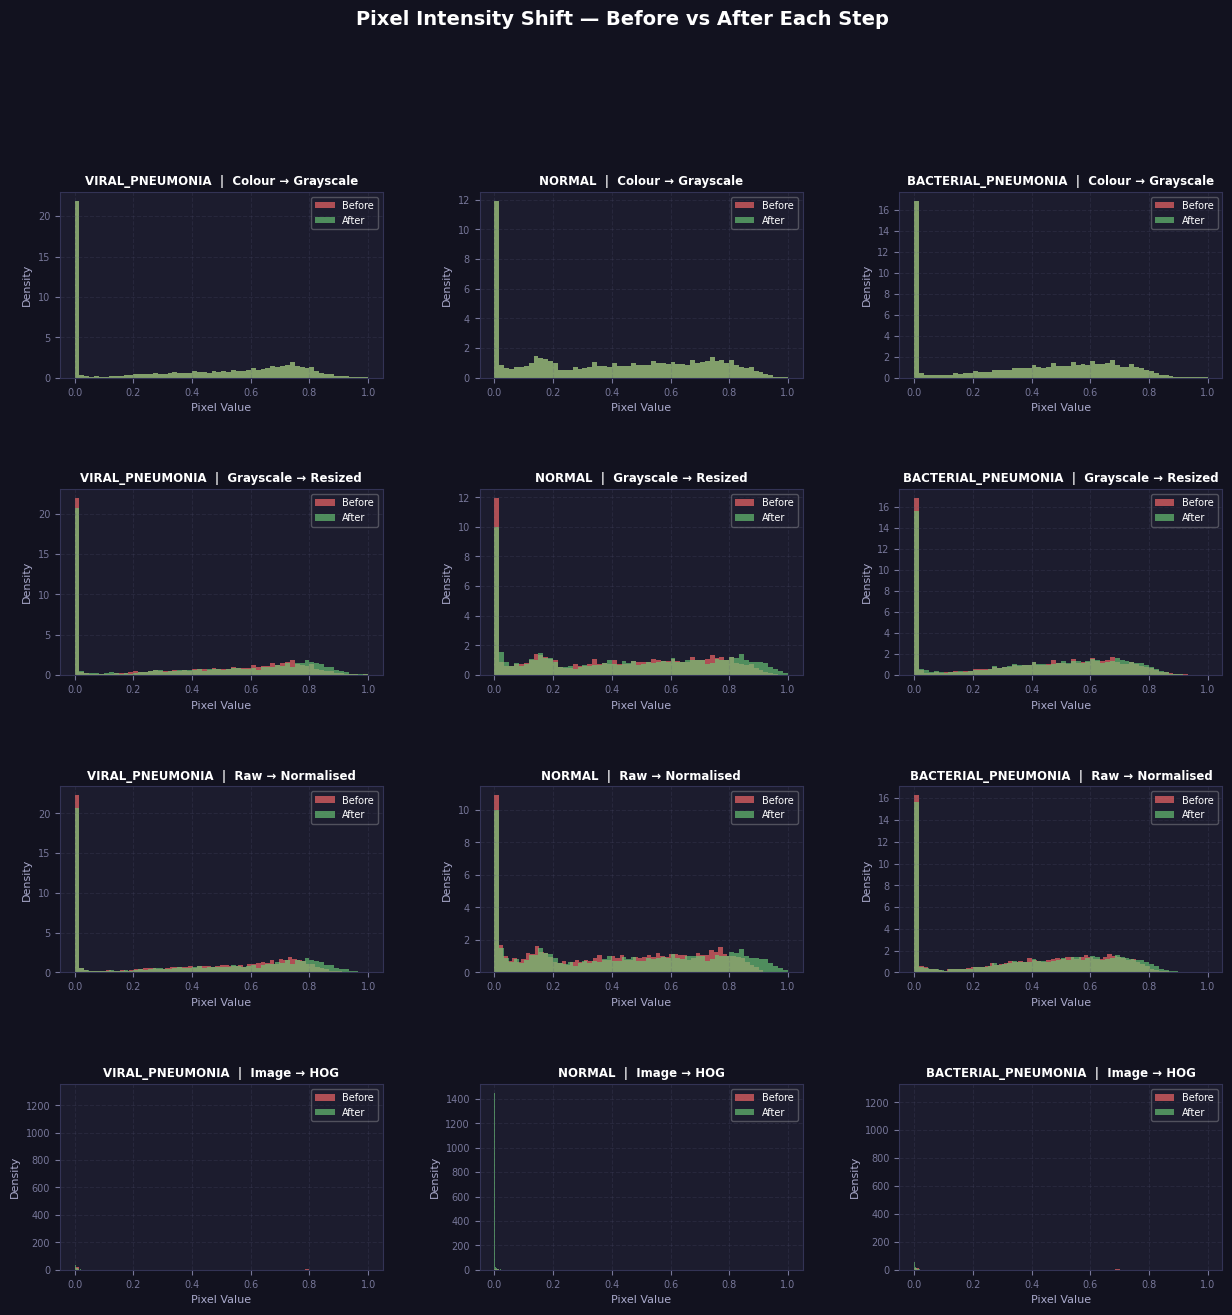

✅ Plot C saved: preproc_C_intensity_shift.png

🎉 All 3 preprocessing before/after plots done.


In [ ]:

# ============================================================
# CELL 3 — Preprocessing Visualisation
#           BEFORE vs AFTER for every step + HOG overlay
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from skimage import io, transform, feature, exposure, filters, util
import warnings
warnings.filterwarnings('ignore')

IMG_SIZE            = (64, 64)
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

# ── Helper: all preprocessing steps ──────────────────────────────────────────
def preprocess_steps(img_path, img_size=IMG_SIZE):
    """Return every intermediate image produced during preprocessing."""
    # BEFORE
    raw        = io.imread(img_path)                         # colour / raw
    raw_gray   = io.imread(img_path, as_gray=True)           # original grayscale (before resize)

    # STEP 1 — grayscale  (before = raw colour, after = gray)
    after_gray = raw_gray.copy()

    # STEP 2 — resize  (before = full-res gray, after = 64×64)
    resized    = transform.resize(raw_gray, img_size,
                                  preserve_range=True,
                                  anti_aliasing=True)
    resized_norm = resized / resized.max() if resized.max() > 0 else resized

    # STEP 3 — normalise  (before = raw pixel range, after = [0,1])
    before_norm = resized.copy()                             # un-normalised resized
    after_norm  = resized_norm.copy()                        # normalised

    # STEP 4 — HOG  (before = normalised img, after = HOG gradient map)
    hog_feat, hog_img = feature.hog(
        resized_norm,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    return {
        'raw'           : raw,
        'raw_gray'      : raw_gray,      # BEFORE step-1
        'after_gray'    : after_gray,    # AFTER  step-1
        'before_resize' : raw_gray,      # BEFORE step-2
        'after_resize'  : resized_norm,  # AFTER  step-2
        'before_norm'   : before_norm,   # BEFORE step-3
        'after_norm'    : after_norm,    # AFTER  step-3
        'before_hog'    : resized_norm,  # BEFORE step-4
        'after_hog'     : hog_img_rescaled,  # AFTER step-4
        'hog_feat'      : hog_feat,
    }

# ── Pick one sample image per class ──────────────────────────────────────────
sample_paths = {}
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if imgs:
        sample_paths[cls] = os.path.join(cls_path, imgs[0])

n_classes = len(sample_paths)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT A — Full pipeline strip (Original → Gray → Resize → Norm → HOG)
# ─────────────────────────────────────────────────────────────────────────────
step_labels = ['① Original\n(raw)', '② Grayscale', '③ Resized\n(64×64)',
               '④ Normalised\n[0–1]', '⑤ HOG Map']
cmaps_strip = ['gray', 'gray', 'gray', 'gray', 'inferno']

fig_A, axes_A = plt.subplots(n_classes, 5,
                              figsize=(5 * 5, 4 * n_classes),
                              gridspec_kw={'wspace': 0.06, 'hspace': 0.3})
if n_classes == 1:
    axes_A = [axes_A]

fig_A.patch.set_facecolor('#1A1A2E')

for row, (cls, img_path) in enumerate(sample_paths.items()):
    s = preprocess_steps(img_path)
    imgs_strip = [s['raw'], s['after_gray'], s['after_resize'],
                  s['after_norm'], s['after_hog']]

    for col, (img, title, cmap) in enumerate(zip(imgs_strip, step_labels, cmaps_strip)):
        ax = axes_A[row][col]
        ax.imshow(img, cmap=cmap)
        ax.set_facecolor('#1A1A2E')
        for sp in ax.spines.values():
            sp.set_edgecolor('#444466')
            sp.set_linewidth(1.2)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if row == 0:
            ax.set_title(title, fontsize=10, fontweight='bold',
                         color='white', pad=6)
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight='bold',
                          color='#A0C4FF', rotation=0,
                          labelpad=60, va='center')
        # Dimension annotation on resize panel
        if col == 2:
            h, w = img.shape[:2]
            ax.text(0.5, -0.08, f'{w}×{h} px', transform=ax.transAxes,
                    ha='center', fontsize=8, color='#AAAACC')
        # Feature dim on HOG panel
        if col == 4:
            ax.text(0.5, -0.08, f'dim={s["hog_feat"].shape[0]}',
                    transform=ax.transAxes, ha='center',
                    fontsize=8, color='#FFAA88')

fig_A.suptitle('Preprocessing Pipeline — Full Strip per Class',
               fontsize=15, fontweight='bold', color='white', y=1.01)
plt.savefig('preproc_A_full_pipeline.png', dpi=150,
            bbox_inches='tight', facecolor='#1A1A2E')
plt.show()
print("✅ Plot A saved: preproc_A_full_pipeline.png")


# ─────────────────────────────────────────────────────────────────────────────
# PLOT B — BEFORE vs AFTER side-by-side for each individual step
#          Rows = steps,  Cols = classes
# ─────────────────────────────────────────────────────────────────────────────
steps_ba = [
    ('Step 1 — Colour → Grayscale',   'raw',          'after_gray',   'gray',    'gray'),
    ('Step 2 — Grayscale → Resized',  'before_resize','after_resize',  'gray',    'gray'),
    ('Step 3 — Raw pixel → Normalised','before_norm', 'after_norm',    'gray',    'gray'),
    ('Step 4 — Image → HOG Map',      'before_hog',   'after_hog',     'gray',    'inferno'),
]
N_STEPS = len(steps_ba)

# Layout: each step gets 2 columns (BEFORE | AFTER) × n_classes subplots
fig_B, axes_B = plt.subplots(
    N_STEPS, n_classes * 2,
    figsize=(n_classes * 5, N_STEPS * 3.2),
    gridspec_kw={'wspace': 0.04, 'hspace': 0.45}
)
if N_STEPS == 1:
    axes_B = [axes_B]
if n_classes * 2 == 1:
    axes_B = [[r] for r in axes_B]

fig_B.patch.set_facecolor('#0F0F1A')

BA_COLORS = {'BEFORE': '#FF6B6B', 'AFTER': '#6BCB77'}

all_data = {cls: preprocess_steps(p) for cls, p in sample_paths.items()}

for step_idx, (step_title, before_key, after_key, cmap_b, cmap_a) in enumerate(steps_ba):
    for cls_idx, cls in enumerate(sample_paths.keys()):
        s = all_data[cls]
        col_b = cls_idx * 2
        col_a = cls_idx * 2 + 1

        for col, key, cmap, tag in [(col_b, before_key, cmap_b, 'BEFORE'),
                                     (col_a, after_key,  cmap_a,  'AFTER')]:
            ax = axes_B[step_idx][col]
            ax.imshow(s[key], cmap=cmap)
            ax.set_facecolor('#0F0F1A')

            # Coloured border: red = BEFORE, green = AFTER
            for sp in ax.spines.values():
                sp.set_edgecolor(BA_COLORS[tag])
                sp.set_linewidth(2.5)
            ax.tick_params(left=False, bottom=False,
                           labelleft=False, labelbottom=False)

            # BEFORE / AFTER badge
            ax.text(0.03, 0.97, tag,
                    transform=ax.transAxes, va='top', ha='left',
                    fontsize=8, fontweight='bold',
                    color='black',
                    bbox=dict(boxstyle='round,pad=0.25',
                              facecolor=BA_COLORS[tag], alpha=0.9, linewidth=0))

            # Class label on top row only
            if step_idx == 0:
                ax.set_title(f'{cls}\n{tag}', fontsize=9,
                             fontweight='bold',
                             color=BA_COLORS[tag], pad=4)

        # Step label on left column only
        if cls_idx == 0:
            axes_B[step_idx][0].set_ylabel(
                step_title, fontsize=9, fontweight='bold',
                color='#CCCCFF', rotation=0,
                labelpad=110, va='center'
            )

    # Separator line between steps
    if step_idx < N_STEPS - 1:
        line_y = 1 - (step_idx + 1) / N_STEPS
        fig_B.add_artist(
            plt.Line2D([0.01, 0.99], [line_y, line_y],
                       transform=fig_B.transFigure,
                       color='#333355', linewidth=1, linestyle='--')
        )

# Legend patches
before_patch = mpatches.Patch(color=BA_COLORS['BEFORE'], label='BEFORE')
after_patch  = mpatches.Patch(color=BA_COLORS['AFTER'],  label='AFTER')
fig_B.legend(handles=[before_patch, after_patch],
             loc='upper right', fontsize=11, framealpha=0.3,
             labelcolor='white', facecolor='#222233')

fig_B.suptitle('Before vs After — Every Preprocessing Step',
               fontsize=15, fontweight='bold', color='white', y=1.01)
plt.savefig('preproc_B_before_after.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()
print("✅ Plot B saved: preproc_B_before_after.png")


# ─────────────────────────────────────────────────────────────────────────────
# PLOT C — Pixel intensity shift: BEFORE vs AFTER for each step (histograms)
# ─────────────────────────────────────────────────────────────────────────────
hist_steps = [
    ('Colour → Grayscale',   'raw_gray',      'after_gray'),
    ('Grayscale → Resized',  'before_resize', 'after_resize'),
    ('Raw → Normalised',     'before_norm',   'after_norm'),
    ('Image → HOG',          'before_hog',    'after_hog'),
]

fig_C, axes_C = plt.subplots(len(hist_steps), n_classes,
                              figsize=(5 * n_classes, 3.5 * len(hist_steps)),
                              gridspec_kw={'hspace': 0.6, 'wspace': 0.3})
if len(hist_steps) == 1:
    axes_C = [axes_C]
if n_classes == 1:
    axes_C = [[r] for r in axes_C]

fig_C.patch.set_facecolor('#12121F')

for step_idx, (step_label, bk, ak) in enumerate(hist_steps):
    for cls_idx, cls in enumerate(sample_paths.keys()):
        s   = all_data[cls]
        ax  = axes_C[step_idx][cls_idx]
        ax.set_facecolor('#1C1C2E')

        before_vals = s[bk].flatten()
        after_vals  = s[ak].flatten()

        ax.hist(before_vals, bins=60, alpha=0.65, density=True,
                color='#FF6B6B', label='Before', edgecolor='none')
        ax.hist(after_vals,  bins=60, alpha=0.65, density=True,
                color='#6BCB77', label='After',  edgecolor='none')

        ax.set_title(f'{cls}  |  {step_label}',
                     fontsize=8.5, fontweight='bold', color='white', pad=5)
        ax.set_xlabel('Pixel Value', fontsize=8, color='#AAAACC')
        ax.set_ylabel('Density',     fontsize=8, color='#AAAACC')
        ax.tick_params(colors='#777799', labelsize=7)
        for sp in ax.spines.values():
            sp.set_edgecolor('#333355')
        ax.legend(fontsize=7, framealpha=0.3, labelcolor='white',
                  facecolor='#222233')
        ax.grid(True, linestyle='--', alpha=0.2, color='#555577')

fig_C.suptitle('Pixel Intensity Shift — Before vs After Each Step',
               fontsize=14, fontweight='bold', color='white', y=1.01)
plt.savefig('preproc_C_intensity_shift.png', dpi=150,
            bbox_inches='tight', facecolor='#12121F')
plt.show()
print("✅ Plot C saved: preproc_C_intensity_shift.png")
print("\n🎉 All 3 preprocessing before/after plots done.")

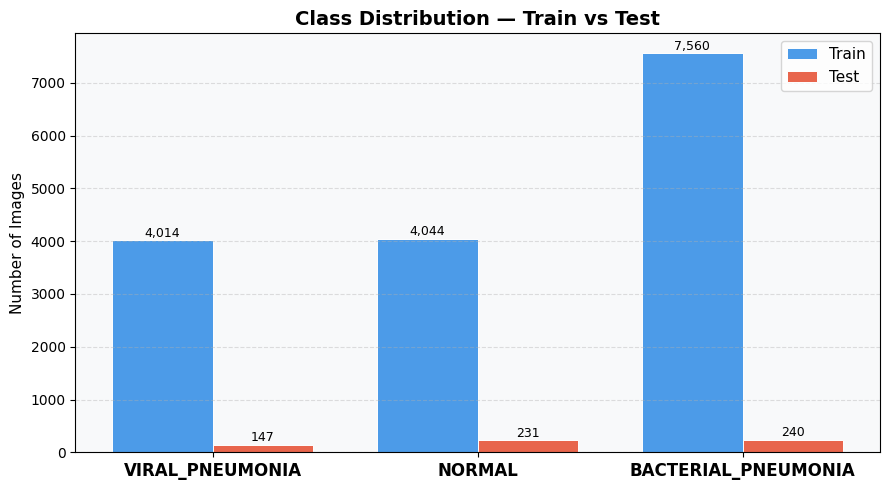

✅ EDA 1/5 — Class distribution saved.


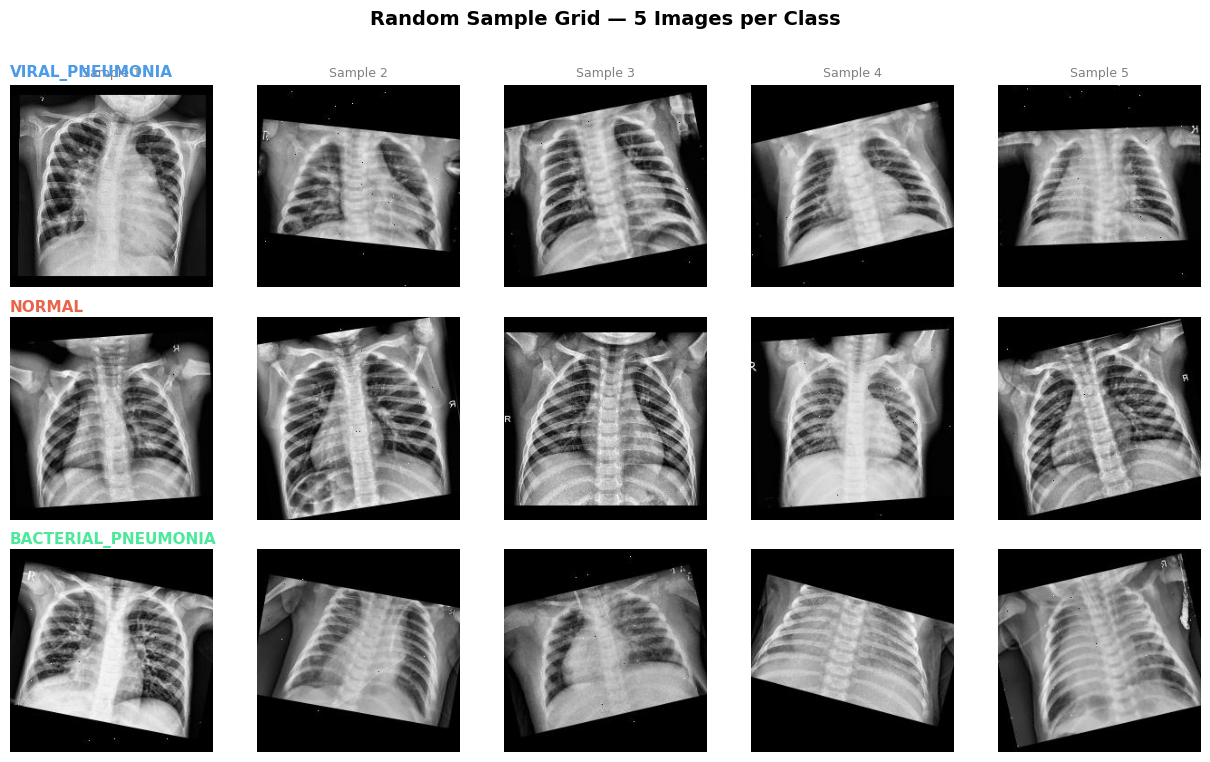

✅ EDA 2/5 — Sample grid saved.


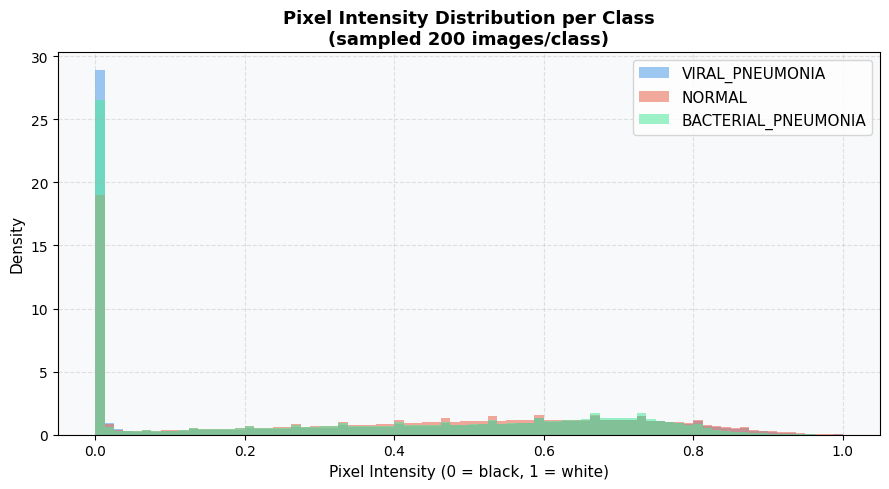

✅ EDA 3/5 — Pixel intensity histogram saved.


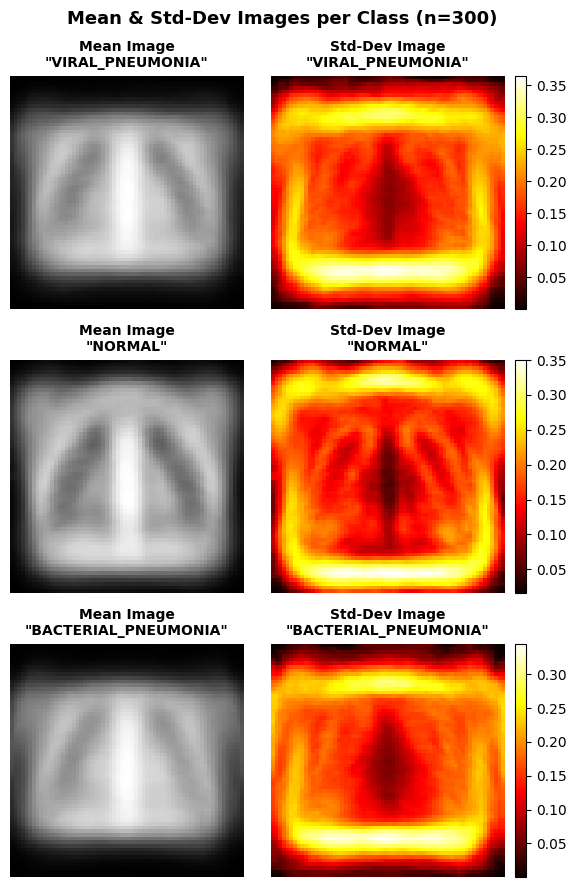

✅ EDA 4/5 — Mean & std-dev images saved.


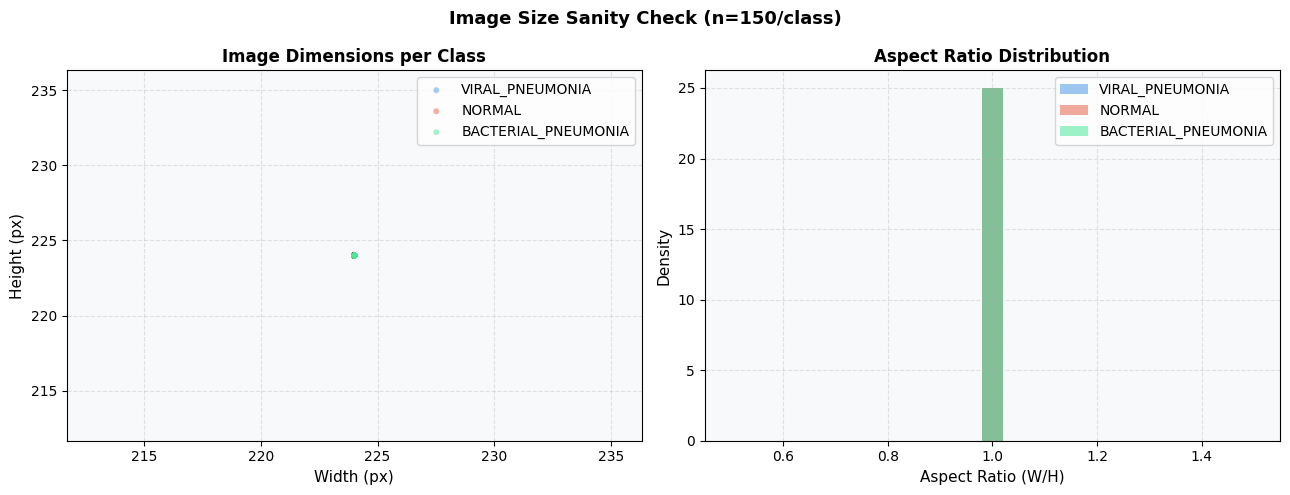

✅ EDA 5/5 — Image size scatter saved.

🎉 EDA complete — all 5 plots generated.


In [ ]:

# ============================================================
# CELL 3B — EDA (Exploratory Data Analysis)
# ============================================================
# Covers:
#   1. Class distribution bar chart (train vs test)
#   2. Sample grid — 5 random images per class
#   3. Pixel intensity histogram per class
#   4. Mean image & std-dev image per class
#   5. Image size / aspect-ratio scatter (sanity check)
# ============================================================

import random
from collections import Counter

palette = ['#4C9BE8', '#E8654C', '#4CE89B', '#E8C44C', '#9B4CE8']  # up to 5 classes

# ── 1. Class distribution bar chart ──────────────────────────────────────────
train_counts = {}
test_counts  = {}
for cls in class_names:
    train_counts[cls] = len([f for f in os.listdir(os.path.join(train_dir, cls))
                              if f.lower().endswith(('.png','.jpg','.jpeg'))])
    test_counts[cls]  = len([f for f in os.listdir(os.path.join(test_dir, cls))
                              if f.lower().endswith(('.png','.jpg','.jpeg'))])

x      = np.arange(len(class_names))
width  = 0.38

fig, ax = plt.subplots(figsize=(max(7, 3 * len(class_names)), 5))
bars1 = ax.bar(x - width/2, [train_counts[c] for c in class_names],
               width, label='Train', color='#4C9BE8', edgecolor='white', linewidth=0.7)
bars2 = ax.bar(x + width/2, [test_counts[c]  for c in class_names],
               width, label='Test',  color='#E8654C', edgecolor='white', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_title('Class Distribution — Train vs Test', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 1/5 — Class distribution saved.")


# ── 2. Random sample grid — 5 images per class ───────────────────────────────
N_SAMPLES = 5
fig, axes = plt.subplots(len(class_names), N_SAMPLES,
                          figsize=(N_SAMPLES * 2.5, len(class_names) * 2.5))
if len(class_names) == 1:
    axes = [axes]

for row, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
    chosen   = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))
    for col in range(N_SAMPLES):
        ax = axes[row][col] if len(class_names) > 1 else axes[col]
        if col < len(chosen):
            img = io.imread(os.path.join(cls_path, chosen[col]), as_gray=True)
            ax.imshow(img, cmap='gray')
        else:
            ax.set_visible(False)
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, fontsize=11, fontweight='bold',
                         loc='left', pad=4, color=palette[row % len(palette)])
        if row == 0 and col < N_SAMPLES:
            ax.set_title(f'Sample {col+1}', fontsize=9, color='gray')

fig.suptitle('Random Sample Grid — 5 Images per Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 2/5 — Sample grid saved.")


# ── 3. Pixel intensity histogram per class ───────────────────────────────────
N_HIST = 200   # images per class to sample for histogram (keep it fast)

fig, ax = plt.subplots(figsize=(9, 5))
for idx, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
    chosen   = random.sample(all_imgs, min(N_HIST, len(all_imgs)))
    all_pixels = []
    for fname in chosen:
        img = io.imread(os.path.join(cls_path, fname), as_gray=True)
        all_pixels.extend(img.flatten().tolist())

    ax.hist(all_pixels, bins=80, alpha=0.55, density=True,
            color=palette[idx % len(palette)], label=cls, edgecolor='none')

ax.set_xlabel('Pixel Intensity (0 = black, 1 = white)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Pixel Intensity Distribution per Class\n(sampled {N_HIST} images/class)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('eda_pixel_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 3/5 — Pixel intensity histogram saved.")


# ── 4. Mean image & std-dev image per class ──────────────────────────────────
N_MEAN = 300   # images per class to compute mean/std

fig, axes = plt.subplots(len(class_names), 2,
                          figsize=(6, 3 * len(class_names)))
if len(class_names) == 1:
    axes = [axes]

for row, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
    chosen   = random.sample(all_imgs, min(N_MEAN, len(all_imgs)))
    stack    = []
    for fname in chosen:
        img = io.imread(os.path.join(cls_path, fname), as_gray=True)
        img = transform.resize(img, IMG_SIZE, preserve_range=True, anti_aliasing=True)
        stack.append(img)
    stack = np.array(stack, dtype=np.float32)

    mean_img = stack.mean(axis=0)
    std_img  = stack.std(axis=0)

    axes[row][0].imshow(mean_img, cmap='gray')
    axes[row][0].set_title(f'Mean Image\n"{cls}"', fontsize=10, fontweight='bold')
    axes[row][0].axis('off')

    im = axes[row][1].imshow(std_img, cmap='hot')
    axes[row][1].set_title(f'Std-Dev Image\n"{cls}"', fontsize=10, fontweight='bold')
    axes[row][1].axis('off')
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)

fig.suptitle(f'Mean & Std-Dev Images per Class (n={N_MEAN})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_mean_std_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 4/5 — Mean & std-dev images saved.")


# ── 5. Image size / aspect-ratio scatter (sanity check) ──────────────────────
N_SCATTER = 150   # images per class to check

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
    chosen   = random.sample(all_imgs, min(N_SCATTER, len(all_imgs)))
    widths, heights, aspects = [], [], []
    for fname in chosen:
        img = io.imread(os.path.join(cls_path, fname), as_gray=True)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        aspects.append(w / h if h > 0 else 1.0)

    c = palette[idx % len(palette)]
    axes[0].scatter(widths, heights, alpha=0.5, s=18, label=cls, color=c, edgecolors='none')
    axes[1].hist(aspects, bins=25, alpha=0.55, color=c, label=cls,
                 density=True, edgecolor='none')

axes[0].set_xlabel('Width (px)',  fontsize=11)
axes[0].set_ylabel('Height (px)', fontsize=11)
axes[0].set_title('Image Dimensions per Class', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.35)
axes[0].set_facecolor('#F8F9FA')

axes[1].set_xlabel('Aspect Ratio (W/H)', fontsize=11)
axes[1].set_ylabel('Density',            fontsize=11)
axes[1].set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.35)
axes[1].set_facecolor('#F8F9FA')

plt.suptitle(f'Image Size Sanity Check (n={N_SCATTER}/class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 5/5 — Image size scatter saved.")
print("\n🎉 EDA complete — all 5 plots generated.")

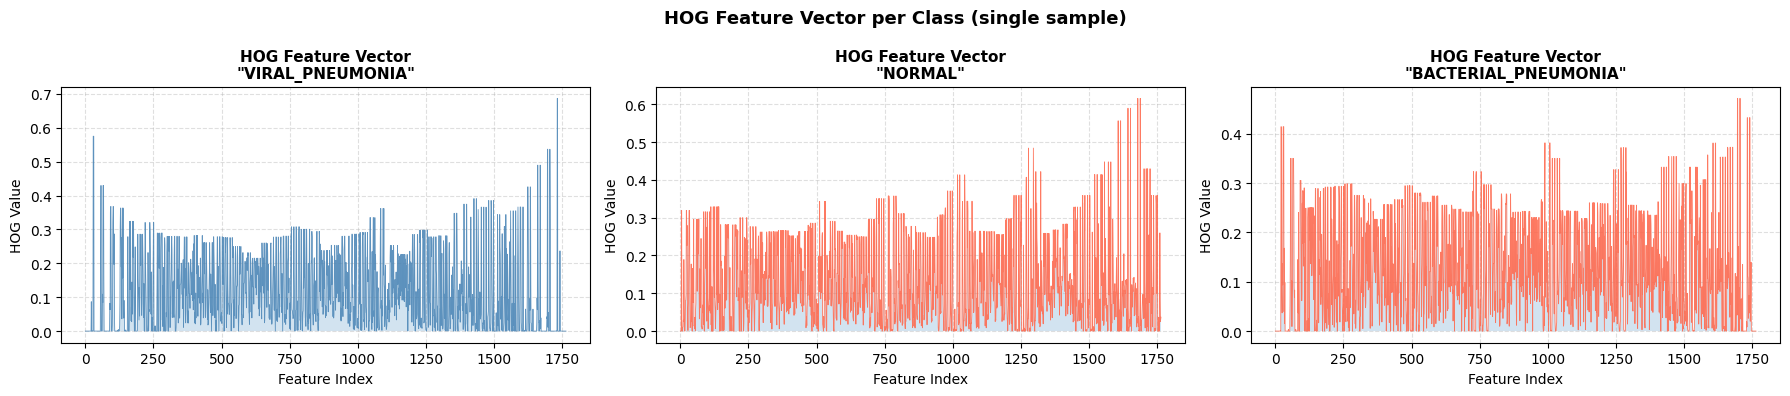

✅ HOG distribution plot saved.


In [ ]:
# ============================================================
# CELL 4 — HOG Feature Vector Distribution Plot
# ============================================================

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 4))
if n_classes == 1:
    axes = [axes]

for ax, (cls, img_path) in zip(axes, sample_paths.items()):
    # The preprocess_steps function returns 8 items in the dictionary. This line unpacks only 5.
    # To fix this, change the unpacking to match the number of returned items.
    s = preprocess_steps(img_path)
    hog_feat = s['hog_feat']
    ax.plot(hog_feat, linewidth=0.6, alpha=0.85,
            color='steelblue' if cls == class_names[0] else 'tomato')
    ax.fill_between(range(len(hog_feat)), hog_feat, alpha=0.2)
    ax.set_title(f'HOG Feature Vector\n"{cls}"', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('HOG Value')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('HOG Feature Vector per Class (single sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ HOG distribution plot saved.")

In [ ]:

# ============================================================
# CELL 5 — Extract HOG Features for All Images
# ============================================================

MAX_PER_CLASS = None   # set e.g. 1000 for faster dev runs

def load_and_extract_features(data_dir, class_names,
                               img_size=IMG_SIZE, max_per_class=None):
    features, labels = [], []
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        img_names = os.listdir(class_path)
        if max_per_class:
            img_names = img_names[:max_per_class]
        for img_name in img_names:
            img_path = os.path.join(class_path, img_name)
            try:
                img = io.imread(img_path, as_gray=True)
                img = transform.resize(img, img_size,
                                       preserve_range=True,
                                       anti_aliasing=True)
                hog_feat = feature.hog(
                    img,
                    orientations=HOG_ORIENTATIONS,
                    pixels_per_cell=HOG_PIXELS_PER_CELL,
                    cells_per_block=HOG_CELLS_PER_BLOCK,
                    block_norm='L2-Hys',
                    visualize=False
                )
                features.append(hog_feat)
                labels.append(class_name)
            except Exception as e:
                print(f"  ⚠️  Error loading {img_path}: {e}")
    return np.array(features), np.array(labels)

print("⏳ Extracting HOG features — training set …")
X_train, y_train = load_and_extract_features(train_dir, class_names,
                                              max_per_class=MAX_PER_CLASS)
print(f"   Train shape: {X_train.shape}")

print("⏳ Extracting HOG features — test set …")
X_test, y_test = load_and_extract_features(test_dir, class_names,
                                            max_per_class=MAX_PER_CLASS)
print(f"   Test  shape: {X_test.shape}")


⏳ Extracting HOG features — training set …
   Train shape: (15618, 1764)
⏳ Extracting HOG features — test set …
   Test  shape: (618, 1764)


⏳ Applying PCA → 100 components …
   After PCA — train: (15618, 100)  |  test: (618, 100)


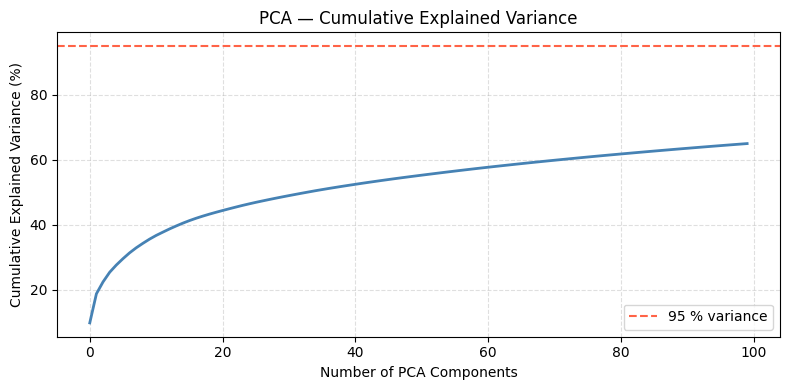

✅ PCA variance plot saved.


In [ ]:
# ============================================================
# CELL 6 — Encode Labels + Standardise + PCA
# ============================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_components = 100
print(f"⏳ Applying PCA → {n_components} components …")
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"   After PCA — train: {X_train_pca.shape}  |  test: {X_test_pca.shape}")

# PCA explained variance plot
plt.figure(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.plot(cumvar, color='steelblue', linewidth=2)
plt.axhline(95, color='tomato', linestyle='--', label='95 % variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA variance plot saved.")

In [ ]:
# ============================================================
# CELL 7 — Train Linear SVM & Random Forest
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

print("⏳ Training Linear SVM …")
svm = LinearSVC(C=1.0, max_iter=1000, random_state=42)
svm.fit(X_train_pca, y_train_enc)
y_pred_svm = svm.predict(X_test_pca)
print("✅ Linear SVM done.")

print("⏳ Training Random Forest …")
rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train_enc)
y_pred_rf = rf.predict(X_test_pca)
print("✅ Random Forest done.")


⏳ Training Linear SVM …
✅ Linear SVM done.
⏳ Training Random Forest …
✅ Random Forest done.



  Linear SVM (with PCA)
                     precision    recall  f1-score   support

    VIRAL_PNEUMONIA       0.76      0.90      0.83       240
             NORMAL       0.94      0.14      0.25       231
BACTERIAL_PNEUMONIA       0.40      0.82      0.54       147

           accuracy                           0.60       618
          macro avg       0.70      0.62      0.54       618
       weighted avg       0.74      0.60      0.54       618



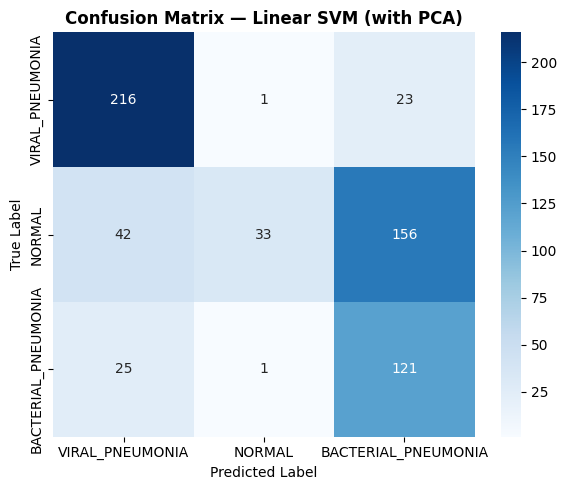


  Random Forest (with PCA)
                     precision    recall  f1-score   support

    VIRAL_PNEUMONIA       0.66      0.94      0.77       240
             NORMAL       0.88      0.26      0.41       231
BACTERIAL_PNEUMONIA       0.41      0.58      0.48       147

           accuracy                           0.60       618
          macro avg       0.65      0.59      0.55       618
       weighted avg       0.68      0.60      0.57       618



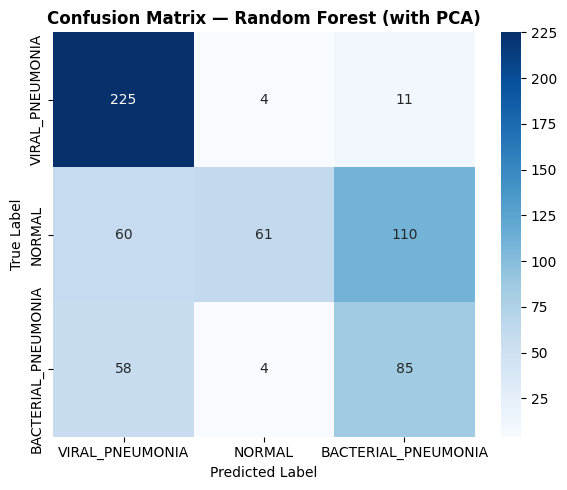

In [ ]:
# ============================================================
# CELL 8 — Evaluation: Classification Report + Confusion Matrix
# ============================================================

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(y_true, y_pred, class_names, model_name):
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print('='*50)
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

evaluate_model(y_test_enc, y_pred_svm, class_names, "Linear SVM (with PCA)")
evaluate_model(y_test_enc, y_pred_rf,  class_names, "Random Forest (with PCA)")


Upload a chest X-ray image (JPG/PNG):


Saving person95_virus_177_jpeg.rf.7e6913bd191b7fd06c0d9b4e0596504c.jpg to person95_virus_177_jpeg.rf.7e6913bd191b7fd06c0d9b4e0596504c (1).jpg


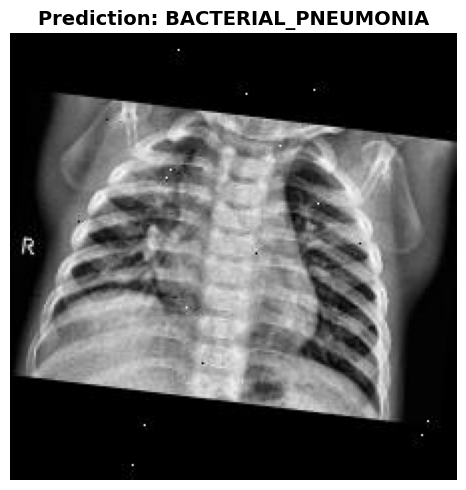

✅ Predicted class: BACTERIAL_PNEUMONIA

🎉 All done.


In [ ]:
# ============================================================
# CELL 9 — Predict a Single Uploaded Image (SVM)
# ============================================================

def predict_single_image(model, pca, scaler, label_encoder, img_size=IMG_SIZE):
    from google.colab import files

    print("\nUpload a chest X-ray image (JPG/PNG):")
    uploaded = files.upload()
    img_path  = list(uploaded.keys())[0]

    img = io.imread(img_path, as_gray=True)
    img_resized = transform.resize(img, img_size,
                                   preserve_range=True,
                                   anti_aliasing=True)
    hog_feat = feature.hog(
        img_resized,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False
    )
    feat_scaled = scaler.transform([hog_feat])
    feat_pca    = pca.transform(feat_scaled)
    pred_enc    = model.predict(feat_pca)[0]
    pred_label  = label_encoder.inverse_transform([pred_enc])[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {pred_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"✅ Predicted class: {pred_label}")

predict_single_image(svm, pca, scaler, label_encoder)
print("\n🎉 All done.")